# ECC Mondrian CQR — Forward Model Backend Comparison

Compares multiple regression backends as the quantile forecaster inside Mondrian CQR:

| Backend | Quantile approach |
|---|---|
| **ET+GBR** | ExtraTrees (q50) + GradientBoosting quantile (q10/q90) |
| **CatBoost** | Native `Quantile:alpha` loss |
| **NGBoost** | Normal distribution via NGBRegressor |
| **LightGBM** | Native `quantile` objective |
| **TabPFN** | Point predictor (Mondrian CQR handles calibration) |

All results are shown inline — no files are written to disk.

In [12]:
import os
import re
import warnings
warnings.filterwarnings('ignore')

os.environ.setdefault('OMP_NUM_THREADS', '1')
os.environ.setdefault('TABPFN_DISABLE_TELEMETRY', '1')
os.environ.setdefault('TABPFN_MODEL_CACHE_DIR', str((__import__('pathlib').Path('../tabpfn_cache')).resolve()))

import numpy as np
import pandas as pd

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import ExtraTreesRegressor, GradientBoostingRegressor

import matplotlib.pyplot as plt

EPS = 1e-8
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

EXCEL_PATH = '/Users/adityagk/Desktop/projects/ECC/data/Tension Test_VIT_re.xlsx'


In [13]:
# Ensure CatBoost is installed
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('catboost') is None:
    print('catboost not found. Installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'catboost'])
    print('catboost installation complete.')
else:
    print('catboost already installed.')

# Ensure Optuna is installed
if importlib.util.find_spec('optuna') is None:
    print('optuna not found. Installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'optuna'])
    print('optuna installation complete.')
else:
    print('optuna already installed.')

# Ensure LightGBM is installed
if importlib.util.find_spec('lightgbm') is None:
    print('lightgbm not found. Installing...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'lightgbm'])
else:
    print('lightgbm already installed.')


catboost already installed.
optuna already installed.
lightgbm already installed.


In [14]:
# Optional backends
HAS_CATBOOST = True
HAS_NGBOOST = True
HAS_OPTUNA = True

try:
    from catboost import CatBoostRegressor
except Exception as e:
    HAS_CATBOOST = False
    print(f'CatBoost unavailable: {e}')

try:
    from ngboost import NGBRegressor
    from ngboost.distns import Normal
except Exception as e:
    HAS_NGBOOST = False
    print(f'NGBoost unavailable: {e}')

try:
    import optuna
except Exception as e:
    HAS_OPTUNA = False
    print(f'Optuna unavailable: {e}')

HAS_LIGHTGBM = True
HAS_TABPFN = True

try:
    import lightgbm as lgb
except Exception as e:
    HAS_LIGHTGBM = False
    print(f'LightGBM unavailable: {e}')

try:
    from tabpfn import TabPFNRegressor
except Exception as e:
    HAS_TABPFN = False
    print(f'TabPFN unavailable (optional): {e}')


TabPFN unavailable (optional): cannot import name 'TabPFNRegressor' from 'tabpfn' (/Users/adityagk/miniconda3/lib/python3.12/site-packages/tabpfn/__init__.py)


In [15]:
# --- Preprocessing from ECC_EXTENDED ---
raw = pd.read_excel(EXCEL_PATH, sheet_name='Tension Test_VIT')
raw.rename(columns={'Water Reducer / SP': 'Water Reducer/SP'}, inplace=True)
df = raw.copy()


def extract_age(row):
    for col in ['Specimen', 'Mixture']:
        v = str(row.get(col, ''))
        m = re.search(r'(\d+)\s*[dD]', v)
        if m:
            return int(m.group(1))
    return None


ages = df.apply(extract_age, axis=1)
mask_drop = ages.notna() & (ages < 28)
df = df[~mask_drop].reset_index(drop=True)

GROUP_COLS = ['Fiber Volume', 'L/D', 'RI', 'Cement', 'Water', 'Sand',
              'Fly ash C', 'Fly ash F', 'GGBS', 'Coarse Aggr.',
              'Silica Fume', 'Water Reducer/SP', 'W/B']
for c in GROUP_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[c] = df[c].fillna(df[c].median())

df['_fp'] = df[GROUP_COLS].round(4).apply(lambda r: '|'.join(map(str, r.values)), axis=1)
df['group_id'] = pd.factorize(df['_fp'])[0]

df['Binder'] = df['Cement'] + df['Fly ash F'] + df['Fly ash C'] + df['GGBS'] + df['Silica Fume']
df['Paste'] = df['Binder'] + df['Water']
df['Total_Aggregates'] = df['Sand'] + df['Coarse Aggr.']

# Group A
df['FA/Binder Ratio'] = (df['Fly ash F'] + df['Fly ash C']) / (df['Binder'] + EPS)
df['S/B Ratio'] = df['Sand'] / (df['Binder'] + EPS)

# Group B
df['Paste Volume'] = df['Paste']
df['SCM Ratio'] = (df['Fly ash F'] + df['Fly ash C'] + df['GGBS'] + df['Silica Fume']) / (df['Cement'] + EPS)
df['Aggregate Ratio'] = df['Total_Aggregates'] / (df['Paste'] + EPS)
df['Fiber Surface Area'] = df['Fiber Volume'] * (df['Length (mm)'] / (df['Diameter (mm)'] + EPS))
df['Fiber Efficiency'] = df['Fiber Volume'] * df['L/D']
df['GGBS Presence'] = (df['GGBS'] > 0).astype(int)
df['Silica Fume Presence'] = (df['Silica Fume'] > 0).astype(int)
df['Coarse Agg Presence'] = (df['Coarse Aggr.'] > 0).astype(int)

# Group C
df['tau_proxy'] = 1.0 / (df['W/B'] + EPS)
df['Flaw Size Proxy'] = df['Aggregate Ratio'] + df['W/B']
df['Geometric Fiber Eff'] = df['Fiber Volume'] * (df['L/D'] ** 2)
df['sigma_cu_proxy'] = df['tau_proxy'] * df['Fiber Volume'] * df['L/D']
df['sigma_crack_proxy'] = 1.0 / (df['Flaw Size Proxy'] + EPS)
df['PSH Strength Index'] = df['sigma_cu_proxy'] / (df['sigma_crack_proxy'] + EPS)
df['Jb_complement'] = df['tau_proxy'] * df['Fiber Volume'] * (df['L/D'] ** 2)
df['J_tip_proxy'] = 1.0 / (df['Flaw Size Proxy'] + EPS)
df['PSH Energy Index'] = df['Jb_complement'] / (df['J_tip_proxy'] + EPS)

ENG_COLS = ['FA/Binder Ratio', 'S/B Ratio', 'Paste Volume', 'SCM Ratio', 'Aggregate Ratio',
            'Fiber Surface Area', 'Fiber Efficiency', 'GGBS Presence', 'Silica Fume Presence',
            'Coarse Agg Presence', 'tau_proxy', 'Flaw Size Proxy', 'Geometric Fiber Eff',
            'sigma_cu_proxy', 'sigma_crack_proxy', 'PSH Strength Index', 'Jb_complement',
            'J_tip_proxy', 'PSH Energy Index']
for c in ENG_COLS:
    df[c] = pd.to_numeric(df[c], errors='coerce').replace([np.inf, -np.inf], np.nan)
    df[c] = df[c].fillna(df[c].median())

RAW_NUMERIC = ['Fiber Volume', 'Length (mm)', 'Diameter (mm)', 'L/D', 'RI',
               'Cement', 'Water', 'Sand', 'Fly ash C', 'Fly ash F', 'GGBS',
               'Coarse Aggr.', 'Silica Fume', 'Water Reducer/SP', 'Fiber',
               'C/B', 'W/C', 'W/B']
for c in RAW_NUMERIC:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    df[c] = df[c].fillna(df[c].median())

if 'Shape Factor' in df.columns:
    df = df.drop(columns=['Shape Factor'])

ALL_37_FEATURES = RAW_NUMERIC + ENG_COLS
TARGETS = ['Second Strain']
for t in TARGETS:
    df[t] = pd.to_numeric(df[t], errors='coerce')
df = df.dropna(subset=TARGETS).reset_index(drop=True)


print(f'Processed shape: {df.shape}')
print(f'Unique compositions: {df.group_id.nunique()}')


Processed shape: (620, 47)
Unique compositions: 276


In [16]:
# Regime definitions from ECC_EXTENDED
REGIME_CUTOFFS = {
    'Second Strain': (0.005, 0.050, 0.0015),
    'Second Stress': (4.0, 5.13, 0.20),
}
REGIME_NAMES = {
    'Second Strain': ('NoPSH', 'Bulk', 'Tail'),
    'Second Stress': ('Weak', 'Mid', 'Strong'),
}


def build_group_means(df_in, target):
    g = df_in.groupby('group_id').agg(
        **{c: (c, 'mean') for c in ALL_37_FEATURES + [target]},
        n_rep=('group_id', 'count'),
        tgt_var=(target, 'var'),
    ).reset_index()
    g['tgt_var'] = g['tgt_var'].fillna(0.0)
    g['sample_weight'] = g['n_rep'] / (g['tgt_var'] + 0.1)

    c1, c2, _ = REGIME_CUTOFFS[target]
    low_name, mid_name, high_name = REGIME_NAMES[target]
    y = g[target].values
    g['regime'] = np.where(y < c1, low_name, np.where(y < c2, mid_name, high_name))
    return g


def mondrian_qhat(cal_scores, cal_q50_pred, val_q50_pred, alpha):
    q33 = np.quantile(cal_q50_pred, 1 / 3)
    q67 = np.quantile(cal_q50_pred, 2 / 3)
    cb = np.where(cal_q50_pred <= q33, 0, np.where(cal_q50_pred <= q67, 1, 2))
    vb = np.where(val_q50_pred <= q33, 0, np.where(val_q50_pred <= q67, 1, 2))
    out = np.zeros(len(val_q50_pred))
    for b in range(3):
        mc, mv = cb == b, vb == b
        n_b = mc.sum()
        if n_b == 0:
            out[mv] = np.quantile(cal_scores, 1 - alpha) if len(cal_scores) else 0
        else:
            lvl = min(np.ceil((n_b + 1) * (1 - alpha)) / n_b, 1.0)
            out[mv] = np.quantile(cal_scores[mc], lvl)
    return out


In [17]:
# Backend model builders

def make_et(params=None):
    params = params or {}
    defaults = dict(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        max_features='sqrt',
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    defaults.update(params)
    return ExtraTreesRegressor(**defaults)


def make_gbr(alpha, params=None):
    params = params or {}
    defaults = dict(
        loss='quantile',
        alpha=alpha,
        n_estimators=200,
        max_depth=3,
        learning_rate=0.05,
        min_samples_leaf=10,
        random_state=RANDOM_SEED,
    )
    defaults.update(params)
    return GradientBoostingRegressor(**defaults)


def make_catboost(alpha, params=None):
    params = params or {}
    defaults = dict(
        loss_function=f'Quantile:alpha={alpha}',
        iterations=500,
        depth=6,
        learning_rate=0.05,
        random_seed=RANDOM_SEED,
        verbose=False,
    )
    defaults.update(params)
    return CatBoostRegressor(**defaults)


def make_ngboost(params=None):
    params = params or {}
    defaults = dict(
        Dist=Normal,
        n_estimators=500,
        learning_rate=0.03,
        random_state=RANDOM_SEED,
        verbose=False,
    )
    defaults.update(params)
    return NGBRegressor(**defaults)




def make_lgbm(alpha, params=None):
    if not HAS_LIGHTGBM:
        raise ImportError('LightGBM not available')
    params = params or {}
    defaults = dict(
        objective='quantile',
        alpha=alpha,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
        verbose=-1,
    )
    defaults.update(params)
    return lgb.LGBMRegressor(**defaults)

def fit_predict_backend(name, X_train, y_train, w_train, X_pred, X_cal=None, y_cal=None, backend_params=None):
    name = name.lower()
    backend_params = backend_params or {}

    if name == 'et+gbr':
        et_params = backend_params.get('et', {})
        gbr_params = backend_params.get('gbr', {})

        m50 = make_et(et_params)
        m50.fit(X_train, y_train, sample_weight=w_train)
        q50 = m50.predict(X_pred)

        m10 = make_gbr(0.10, gbr_params)
        m10.fit(X_train, y_train, sample_weight=w_train)
        q10 = m10.predict(X_pred)

        m90 = make_gbr(0.90, gbr_params)
        m90.fit(X_train, y_train, sample_weight=w_train)
        q90 = m90.predict(X_pred)
        return q10, q50, q90

    if name == 'catboost':
        cb_params = backend_params.get('catboost', {})

        m50 = make_catboost(0.50, cb_params)
        m50.fit(X_train, y_train, sample_weight=w_train)
        q50 = m50.predict(X_pred)

        m10 = make_catboost(0.10, cb_params)
        m10.fit(X_train, y_train, sample_weight=w_train)
        q10 = m10.predict(X_pred)

        m90 = make_catboost(0.90, cb_params)
        m90.fit(X_train, y_train, sample_weight=w_train)
        q90 = m90.predict(X_pred)
        return q10, q50, q90

    if name == 'ngboost':
        ngb_params = backend_params.get('ngboost', {})

        m = make_ngboost(ngb_params)
        m.fit(X_train, y_train, sample_weight=w_train)
        dist = m.pred_dist(X_pred)
        q10 = np.asarray(dist.ppf(0.10)).ravel()
        q50 = np.asarray(dist.ppf(0.50)).ravel()
        q90 = np.asarray(dist.ppf(0.90)).ravel()
        return q10, q50, q90


    if name == 'lightgbm':
        lgb_params = backend_params.get('lightgbm', {})
        m50 = make_lgbm(0.50, lgb_params)
        m50.fit(X_train, y_train, sample_weight=w_train)
        q50 = m50.predict(X_pred)
        m10 = make_lgbm(0.10, lgb_params)
        m10.fit(X_train, y_train, sample_weight=w_train)
        q10 = m10.predict(X_pred)
        m90 = make_lgbm(0.90, lgb_params)
        m90.fit(X_train, y_train, sample_weight=w_train)
        q90 = m90.predict(X_pred)
        return q10, q50, q90

    if name == 'tabpfn':
        # TabPFN as point predictor — CQR provides interval calibration
        tfn_params = backend_params.get('tabpfn', {})
        defaults = dict(n_estimators=4, random_state=RANDOM_SEED)
        defaults.update(tfn_params)
        m = TabPFNRegressor(**defaults)
        m.fit(X_train, y_train)
        q50 = m.predict(X_pred)
        q50 = np.maximum(q50, 0)
        q10, q90 = q50, q50  # CQR calibration handles interval width
        return q10, q50, q90

    raise ValueError(f'Unknown backend: {name}')


In [18]:
def run_backend_cv(g, target, backend, alpha=0.20, backend_params=None):
    gkf = GroupKFold(n_splits=5)
    y_all = g[target].values
    groups_arr = g['group_id'].values

    N = len(g)
    p50 = np.full(N, np.nan)
    lo = np.full(N, np.nan)
    hi = np.full(N, np.nan)

    for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(g, y_all, groups_arr), start=1):
        gdf_tr = g.iloc[tr_idx].reset_index(drop=True)
        gdf_va = g.iloc[val_idx].reset_index(drop=True)

        y_tr = gdf_tr[target].values
        w_tr = gdf_tr['sample_weight'].values

        # 75/25 fit/cal split by composition
        tr_uniq = gdf_tr['group_id'].unique()
        rng = np.random.default_rng(fold_idx)
        rng.shuffle(tr_uniq)
        n_fit = int(0.75 * len(tr_uniq))
        fit_grp = set(tr_uniq[:n_fit])

        fit_mask = gdf_tr['group_id'].isin(fit_grp).values
        cal_mask = ~fit_mask

        X_tr = gdf_tr[ALL_37_FEATURES].values
        X_fit = gdf_tr.loc[fit_mask, ALL_37_FEATURES].values
        X_cal = gdf_tr.loc[cal_mask, ALL_37_FEATURES].values
        X_va = gdf_va[ALL_37_FEATURES].values

        y_fit = y_tr[fit_mask]
        y_cal = y_tr[cal_mask]
        w_fit = w_tr[fit_mask]

        # Full-train predictions for validation
        q10_va, q50_va, q90_va = fit_predict_backend(
            backend, X_tr, y_tr, w_tr, X_va, X_cal=X_cal, y_cal=y_cal, backend_params=backend_params
        )

        # Fit-split predictions for calibration and validation qhat bins
        q10_cal, q50_cal, q90_cal = fit_predict_backend(
            backend, X_fit, y_fit, w_fit, X_cal, X_cal=X_cal, y_cal=y_cal, backend_params=backend_params
        )
        _, q50_va_fit, _ = fit_predict_backend(
            backend, X_fit, y_fit, w_fit, X_va, X_cal=X_cal, y_cal=y_cal, backend_params=backend_params
        )

        scores = np.maximum(q10_cal - y_cal, y_cal - q90_cal)
        qhat = mondrian_qhat(scores, q50_cal, q50_va_fit, alpha)

        p50[val_idx] = np.maximum(q50_va, 0)
        lo[val_idx] = np.maximum(q10_va - qhat, 0)
        hi[val_idx] = np.maximum(q90_va + qhat, 0)

    y_true = g[target].values
    regime = g['regime'].values
    low_name, mid_name, high_name = REGIME_NAMES[target]

    metrics = {
        'MAE': mean_absolute_error(y_true, p50),
        'RMSE': np.sqrt(mean_squared_error(y_true, p50)),
        'R2': r2_score(y_true, p50),
        'Cov80': np.mean((y_true >= lo) & (y_true <= hi)),
        'Width80': np.mean(hi - lo),
    }

    for r in [low_name, mid_name, high_name]:
        mk = regime == r
        metrics[f'MAE_{r}'] = mean_absolute_error(y_true[mk], p50[mk]) if mk.sum() else np.nan
        metrics[f'Cov_{r}'] = np.mean((y_true[mk] >= lo[mk]) & (y_true[mk] <= hi[mk])) if mk.sum() else np.nan
        metrics[f'Width_{r}'] = np.mean(hi[mk] - lo[mk]) if mk.sum() else np.nan

    return metrics, p50, lo, hi


In [19]:
def plot_backend_results(target, g, results_df, preds_store):
    # 1) Metrics bar
    plt.figure(figsize=(10, 5))
    x = np.arange(len(results_df))
    plt.bar(x - 0.2, results_df['MAE'].values, width=0.2, label='MAE')
    plt.bar(x, results_df['RMSE'].values, width=0.2, label='RMSE')
    plt.bar(x + 0.2, results_df['R2'].values, width=0.2, label='R2')
    plt.xticks(x, results_df.index, rotation=20)
    plt.title(f'{target}: Point Metrics by Backend')
    plt.grid(axis='y', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Coverage-width chart
    fig, ax1 = plt.subplots(figsize=(10, 5))
    ax2 = ax1.twinx()
    ax1.bar(results_df.index, results_df['Cov80'].values, color='#4a90d9', alpha=0.7, label='Cov80')
    ax2.plot(results_df.index, results_df['Width80'].values, color='#d94a4a', marker='o', label='Width80')
    ax1.set_ylim(0, 1.05)
    ax1.set_ylabel('Coverage')
    ax2.set_ylabel('Interval Width')
    ax1.set_title(f'{target}: Interval Metrics by Backend')
    ax1.grid(axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()

    # 3) Scatter + interval panels per backend
    y_true = g[target].values
    sort_idx = np.argsort(y_true)
    n = len(results_df)
    fig, axes = plt.subplots(n, 2, figsize=(14, 4 * n))
    if n == 1:
        axes = np.array([axes])

    for i, backend in enumerate(results_df.index):
        p50, lo, hi = preds_store[backend]

        ax = axes[i, 0]
        ax.scatter(y_true, p50, s=24, alpha=0.7)
        lim = max(np.max(y_true), np.max(p50)) * 1.05
        ax.plot([0, lim], [0, lim], 'k--', alpha=0.5)
        ax.set_title(f'{backend} scatter | MAE={results_df.loc[backend, "MAE"]:.4f}, R2={results_df.loc[backend, "R2"]:.4f}')
        ax.set_xlabel('True')
        ax.set_ylabel('Predicted q50')
        ax.grid(alpha=0.3)

        ax = axes[i, 1]
        x = np.arange(len(y_true))
        ax.fill_between(x, lo[sort_idx], hi[sort_idx], color='gray', alpha=0.3, label='80% CI')
        ax.plot(x, y_true[sort_idx], 'k-', lw=1.2, label='True')
        ax.plot(x, p50[sort_idx], color='orange', lw=1.0, ls='--', label='Pred q50')
        ax.set_title(f'{backend} intervals | Cov80={results_df.loc[backend, "Cov80"]:.3f}, Width80={results_df.loc[backend, "Width80"]:.4f}')
        ax.set_xlabel('Group rank')
        ax.set_ylabel(target)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    plt.tight_layout()
    plt.show()


In [20]:
# Optional Optuna tuning for ET+GBR, CatBoost, NGBoost
USE_OPTUNA_TUNING = False
N_TRIALS = 20


# Paste your tuned best params here (from backend_best_params_optuna.csv)
PRESET_BEST_PARAMS = {
    'ET+GBR': {
        'et': {
            'n_estimators': 800,
            'max_depth': 12,
            'min_samples_leaf': 1,
            'max_features': 'sqrt',
        },
        'gbr': {
            'n_estimators': 350,
            'max_depth': 2,
            'learning_rate': 0.05687116530845548,
            'min_samples_leaf': 14,
        },
    },
    'CatBoost': {
        'catboost': {
            'iterations': 600,
            'depth': 9,
            'learning_rate': 0.12604670759479358,
            'l2_leaf_reg': 0.2919794366938302,
        },
    },
    'NGBoost': {
        'ngboost': {
            'n_estimators': 900,
            'learning_rate': 0.05231624682085454,
        },
    },
}



def suggest_params(trial, backend):
    if backend == 'ET+GBR':
        return {
            'et': {
                'n_estimators': trial.suggest_int('et_n_estimators', 200, 800, step=100),
                'max_depth': trial.suggest_int('et_max_depth', 6, 24),
                'min_samples_leaf': trial.suggest_int('et_min_samples_leaf', 1, 8),
                'max_features': trial.suggest_categorical('et_max_features', ['sqrt', 'log2']),
            },
            'gbr': {
                'n_estimators': trial.suggest_int('gbr_n_estimators', 100, 400, step=50),
                'max_depth': trial.suggest_int('gbr_max_depth', 2, 6),
                'learning_rate': trial.suggest_float('gbr_learning_rate', 0.01, 0.15, log=True),
                'min_samples_leaf': trial.suggest_int('gbr_min_samples_leaf', 3, 20),
            },
        }

    if backend == 'CatBoost':
        return {
            'catboost': {
                'iterations': trial.suggest_int('cb_iterations', 200, 800, step=100),
                'depth': trial.suggest_int('cb_depth', 4, 10),
                'learning_rate': trial.suggest_float('cb_learning_rate', 0.01, 0.2, log=True),
                'l2_leaf_reg': trial.suggest_float('cb_l2_leaf_reg', 1e-2, 20.0, log=True),
            }
        }

    if backend == 'NGBoost':
        return {
            'ngboost': {
                'n_estimators': trial.suggest_int('ngb_n_estimators', 200, 900, step=100),
                'learning_rate': trial.suggest_float('ngb_learning_rate', 0.005, 0.1, log=True),
            }
        }

    return {}


def tune_backend_with_optuna(g, target, backend, n_trials=20):
    def objective(trial):
        params = suggest_params(trial, backend)
        metrics, _, _, _ = run_backend_cv(g, target, backend, alpha=0.20, backend_params=params)
        return metrics['MAE']

    study = optuna.create_study(direction='minimize')
    study.optimize(objective, n_trials=n_trials)
    return suggest_params(study.best_trial, backend), study.best_value


Backends to evaluate: ['ET+GBR', 'CatBoost', 'NGBoost', 'LightGBM']

TARGET: Second Strain


Using preset params for ET+GBR: {'et': {'n_estimators': 800, 'max_depth': 12, 'min_samples_leaf': 1, 'max_features': 'sqrt'}, 'gbr': {'n_estimators': 350, 'max_depth': 2, 'learning_rate': 0.05687116530845548, 'min_samples_leaf': 14}}
Using preset params for CatBoost: {'catboost': {'iterations': 600, 'depth': 9, 'learning_rate': 0.12604670759479358, 'l2_leaf_reg': 0.2919794366938302}}
Using preset params for NGBoost: {'ngboost': {'n_estimators': 900, 'learning_rate': 0.05231624682085454}}
Using preset params for LightGBM: {}
Running backend: ET+GBR
Running backend: CatBoost
Running backend: NGBoost
Running backend: LightGBM


,MAE,RMSE,R2,Cov80,Width80,MAE_NoPSH,Cov_NoPSH,Width_NoPSH,MAE_Bulk,Cov_Bulk,Width_Bulk,MAE_Tail,Cov_Tail,Width_Tail
Backend,,,,,,,,,,,,,,
ET+GBR,0.00772,0.01236,0.54698,0.81884,0.03749,0.00248,0.74648,0.02513,0.00821,0.86885,0.03966,0.02057,0.63636,0.05933
CatBoost,0.00733,0.01225,0.55553,0.85507,0.02854,0.00264,0.85915,0.00966,0.00765,0.87432,0.03367,0.01987,0.68182,0.04688
NGBoost,0.00782,0.01243,0.54209,0.89855,0.03433,0.00281,0.91549,0.01154,0.00821,0.91257,0.04072,0.02074,0.72727,0.05467
LightGBM,0.01045,0.01607,0.23442,0.88043,0.03906,0.00221,0.91549,0.02258,0.01093,0.89617,0.04289,0.03310,0.63636,0.06044


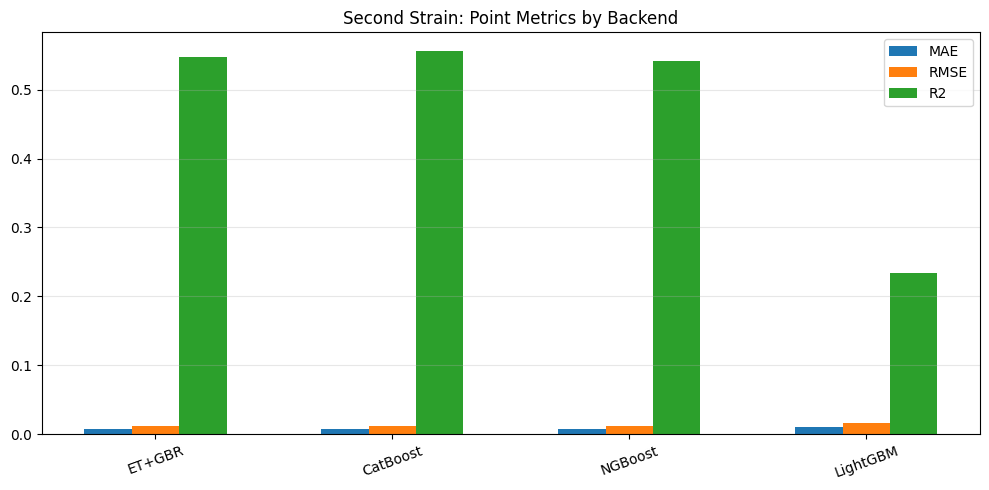

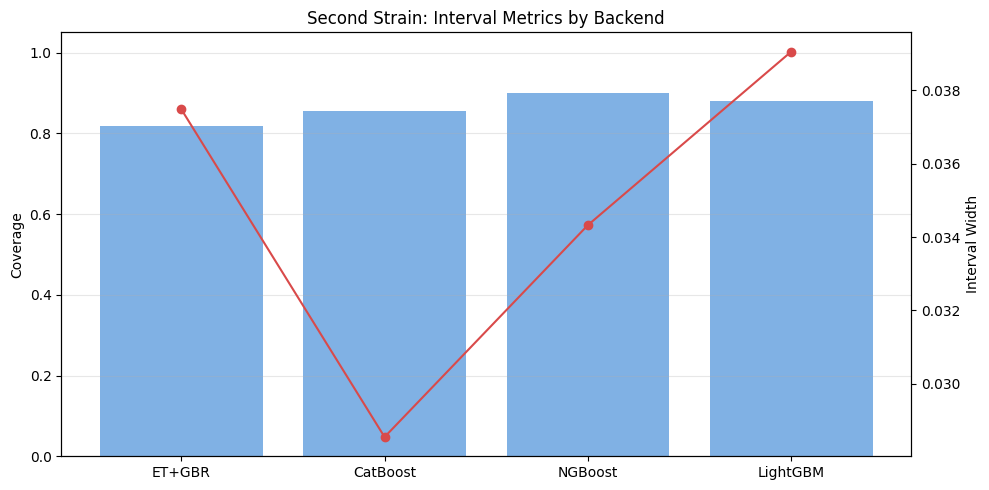

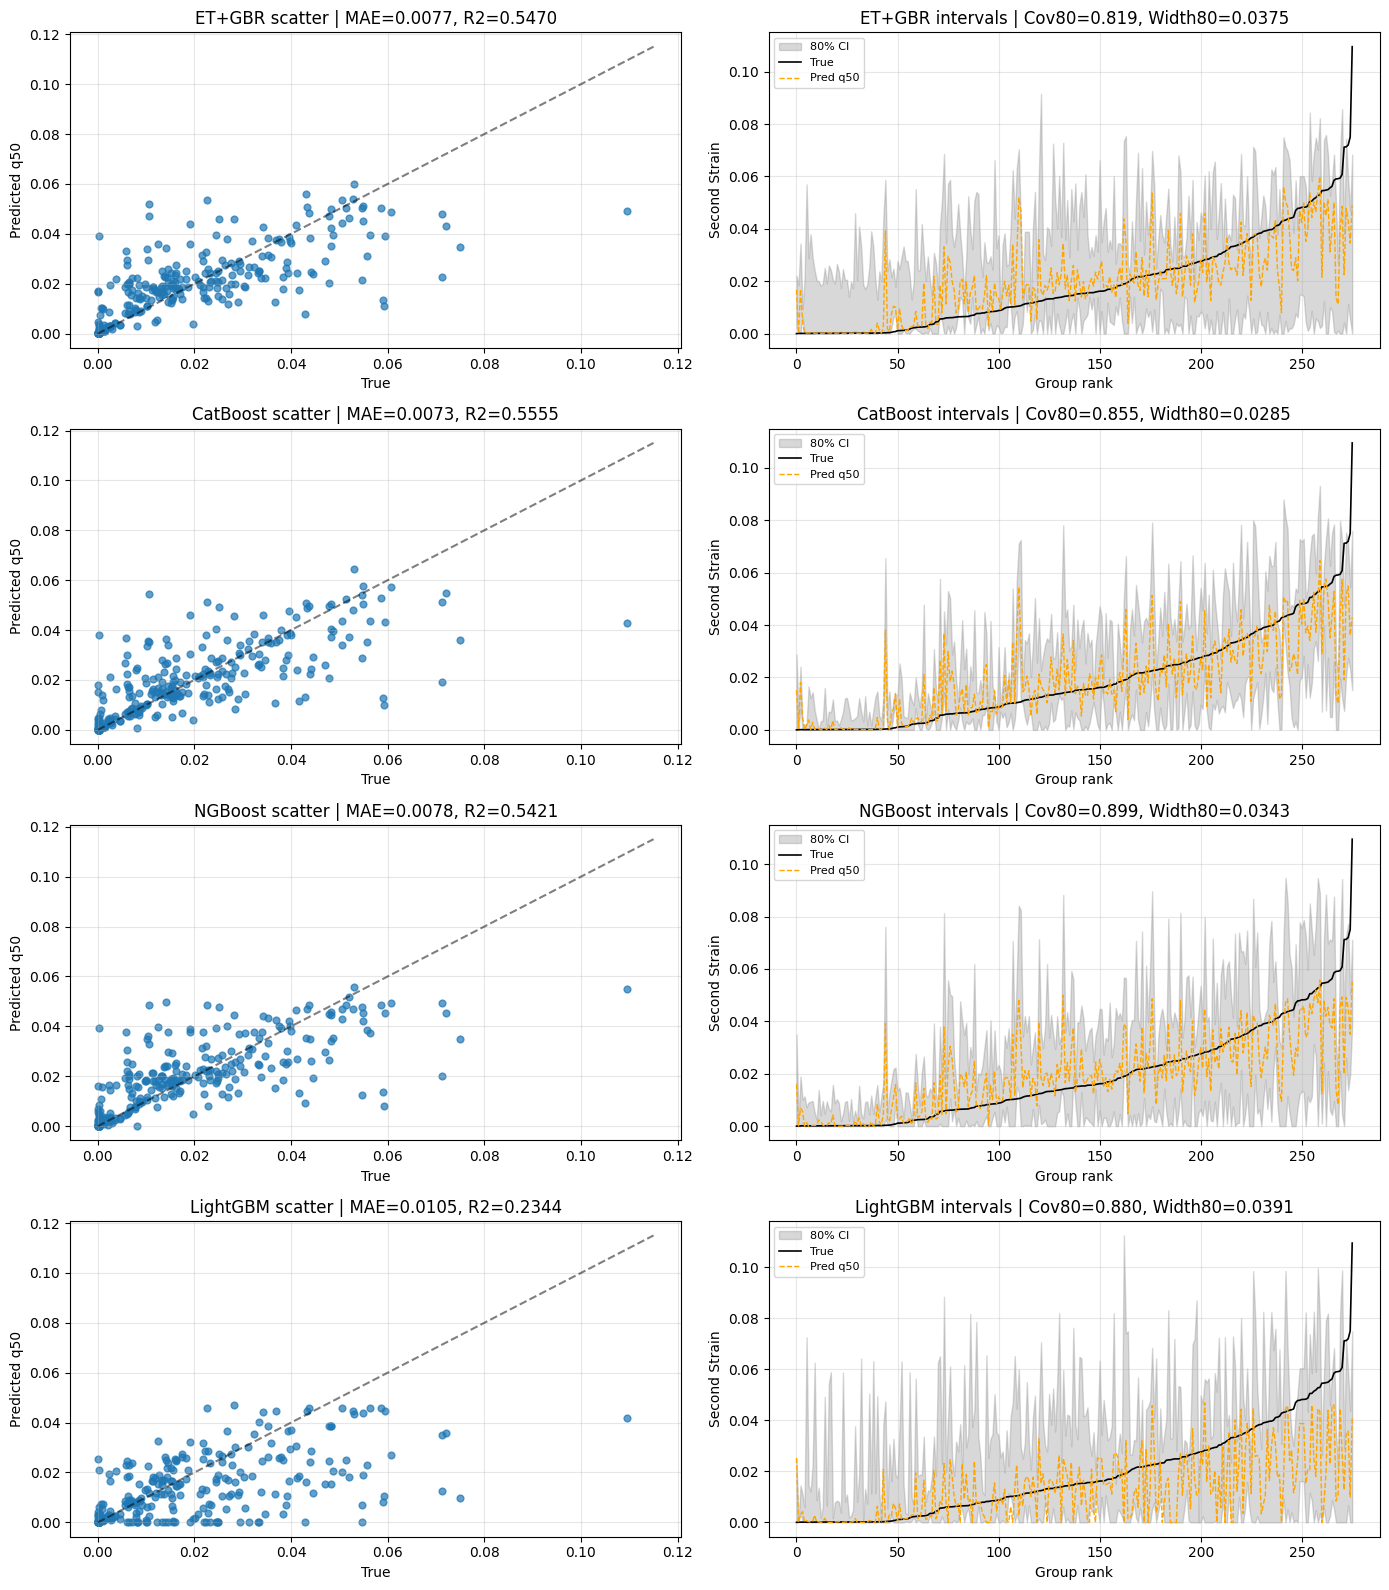

In [21]:
# Run full comparison
backend_list = ['ET+GBR']
if HAS_CATBOOST:
    backend_list.append('CatBoost')
if HAS_NGBOOST:
    backend_list.append('NGBoost')
if HAS_LIGHTGBM:
    backend_list.append('LightGBM')
if HAS_TABPFN:
    backend_list.append('TabPFN')

print('Backends to evaluate:', backend_list)

ALL_RESULTS = {}
BEST_PARAMS = {}

for target in TARGETS:
    print('\n' + '=' * 80)
    print(f'TARGET: {target}')
    print('=' * 80)

    g = build_group_means(df, target)

    # Parameter source: tune (optional) or reuse preset best params
    for backend in backend_list:
        if USE_OPTUNA_TUNING and HAS_OPTUNA:
            print(f'Tuning backend with Optuna: {backend}')
            best_params, best_mae = tune_backend_with_optuna(g, target, backend, n_trials=N_TRIALS)
            BEST_PARAMS[(target, backend)] = best_params
            print(f'  Best MAE: {best_mae:.6f}')
            print(f'  Best params: {best_params}')
        else:
            BEST_PARAMS[(target, backend)] = PRESET_BEST_PARAMS.get(backend, {})
            print(f'Using preset params for {backend}: {BEST_PARAMS[(target, backend)]}')

    rows = []
    preds_store = {}
    for backend in backend_list:
        print(f'Running backend: {backend}')
        metrics, p50, lo, hi = run_backend_cv(
            g,
            target,
            backend,
            alpha=0.20,
            backend_params=BEST_PARAMS.get((target, backend), {}),
        )
        metrics['Backend'] = backend
        rows.append(metrics)
        preds_store[backend] = (p50, lo, hi)

    res_df = pd.DataFrame(rows).set_index('Backend')
    ALL_RESULTS[target] = {
        'metrics': res_df,
        'preds': preds_store,
        'group_df': g,
    }

    display(res_df.round(5))
    plot_backend_results(target, g, res_df, preds_store)


In [22]:
# Summary table of all results
for target, obj in ALL_RESULTS.items():
    print(f'\n{target}:')
    display(obj['metrics'].round(5))



Second Strain:


,MAE,RMSE,R2,Cov80,Width80,MAE_NoPSH,Cov_NoPSH,Width_NoPSH,MAE_Bulk,Cov_Bulk,Width_Bulk,MAE_Tail,Cov_Tail,Width_Tail
Backend,,,,,,,,,,,,,,
ET+GBR,0.00772,0.01236,0.54698,0.81884,0.03749,0.00248,0.74648,0.02513,0.00821,0.86885,0.03966,0.02057,0.63636,0.05933
CatBoost,0.00733,0.01225,0.55553,0.85507,0.02854,0.00264,0.85915,0.00966,0.00765,0.87432,0.03367,0.01987,0.68182,0.04688
NGBoost,0.00782,0.01243,0.54209,0.89855,0.03433,0.00281,0.91549,0.01154,0.00821,0.91257,0.04072,0.02074,0.72727,0.05467
LightGBM,0.01045,0.01607,0.23442,0.88043,0.03906,0.00221,0.91549,0.02258,0.01093,0.89617,0.04289,0.03310,0.63636,0.06044
